In [1]:
import pyterrier as pt
import matplotlib.pyplot as plt
import pandas as pd
import os
from ir_measures import *
import textwrap
from ir_measures import *

run_dir = "./runs/"
pd.set_option('display.max_rows', 500)

import pyterrier as pt
if not pt.started():
    pt.init()

/tmp/ipykernel_2758/1215778460.py:13: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_2758/1215778460.py:14: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


In [2]:
docs = pd.read_pickle("/nfs/primary/sas_reranker/ohsumed_docs_w_t5base_sensitivity.pkl")
queries = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/queries.pkl")
qrels = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/qrels.pkl")

In [3]:
runs = []
run_names = []
for run in os.listdir("/nfs/primary/SPLADE/splade_sans/rq3/runs/"):
    if "checkpoint" not in run and "splade" in run:
        runs.append(pt.io.read_results(f"/nfs/primary/SPLADE/splade_sans/rq3/runs/{run}"))
        run_names.append(run)

def _sens_docs(qrels, run):
    if "sensitivity" in run.columns:
        run = run.drop(columns = ["sensitivity"])
    merged = pd.merge(run, docs, left_on = "doc_id", right_on = "docno")
    return merged.sensitivity.sum()
    
import ir_measures
sens_docs = ir_measures.define_byquery(
    _sens_docs, 
    name="sens_docs")

distil_results = pt.Experiment(
    runs,
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = run_names
)



runs = []
run_names = []
for run in os.listdir("./sans_baselines/"):
    runs.append(pt.io.read_results(f"./sans_baselines/{run}"))
    run_names.append(run)

sans_results = pt.Experiment(
    runs[2:],
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = run_names[2:]
)

add_results = pt.Experiment(
    [
        pt.io.read_results("../splade_class/runs/splade_ohsumed_8_negs_add.run"),
        pt.io.read_results("/nfs/primary/SPLADE/splade_sans/rq3/runs/splade_max_strategy1_distil"),
        # pt.io.read_results("/nfs/primary/SPLADE/splade_sans/rq3/runs/splade_max_strategy2_distil"),
        pt.io.read_results("/nfs/primary/SPLADE/splade_sans/rq3/runs/splade_max_strategy3_distil")
    ],
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = [
        "Learned Vocabulary (Add) (OHSUMED 8 Negs)",
        "Distill Strategy 1",
        # "Distill Strategy 2",
        "Distill Strategy 3"
    ]
)

sans_results = sans_results.rename(columns = {"name" : "Approach"})
distil_results = distil_results.rename(columns = {"name" : "Approach"})
add_results = add_results.rename(columns = {"name" : "Approach"})

In [4]:
results = pd.read_csv("./SAS Splade Results - Sheet1.csv")
results = pd.concat([results, sans_results, add_results])
results
results = results[~results.astype(str).apply(lambda row: row.str.contains('cocondeser', case=False, na=False)).any(axis=1)]
results = results[~results.astype(str).apply(lambda row: row.str.contains('cocondenser', case=False, na=False)).any(axis=1)]
results

,Approach,nDCG@10,sens_docs@10,Run File
0,SPLADE (OHSUMED 8 Negs),0.437492,1.216981,nfs/SPLADE/splade_class/runs/splade_ohsumed_mu...
1,SPLADE >> SVM Filter,0.360254,0.943396,nfs/SPLADE/splade_class/runs/splade_ohsumed_mu...
2,SPLADE >> T5 Filter,0.428907,1.028302,nfs/SPLADE/splade_class/runs/splade_ohsumed_mu...
3,SPLADE SANS Strategy 1,0.455684,0.830189,nfs/SPLADE/splade_sans/runs/splade_max_strateg...
4,SPLADE SANS Strategy 2,0.467844,1.301887,nfs/SPLADE/splade_sans/runs/splade_max_strateg...
5,SPLADE SANS Strategy 3,0.461892,1.462264,nfs/SPLADE/splade_sans/runs/splade_max_strateg...
6,SPLADE Combined Classification and Ranking,0.407353,0.509434,nfs/SPLADE/splade_sans/runs_v2/splade_combined_v1
9,Sensitivity Regularisation (Best training point),0.310000,0.886790,NaN
10,Sensitivity Regularisation Learned Weight (Bes...,0.393130,1.226420,NaN
0,monot5_random_neg,0.329744,0.698113,NaN


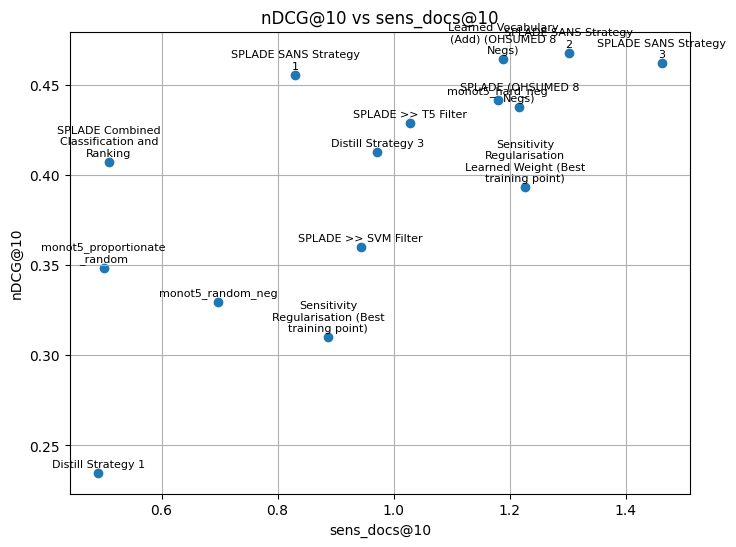

In [5]:
def wrap_text(text, width=20):
    return "\n".join(textwrap.wrap(text, width=width))

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(results["sens_docs@10"], results["nDCG@10"])

# Annotate each point with wrapped 'name' value
for i, row in results.iterrows():
    wrapped_name = wrap_text(str(row["Approach"]), width=20)
    plt.text(row["sens_docs@10"], row["nDCG@10"] + 0.002, wrapped_name, 
             fontsize=8, ha='center', va='bottom')

# Labels and title
plt.xlabel("sens_docs@10")
plt.ylabel("nDCG@10")
plt.title("nDCG@10 vs sens_docs@10")

# Grid for better readability
plt.grid(True)

# Show the plot
plt.show()

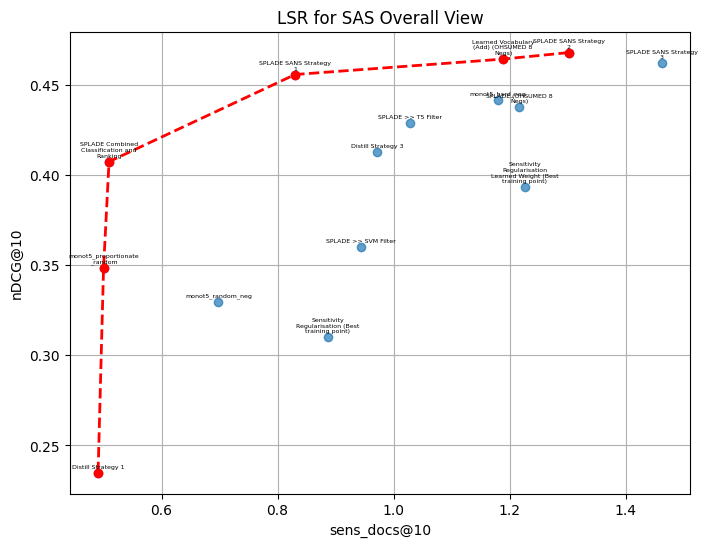

In [6]:
import numpy as np
# Identify Pareto optimal points
def find_pareto_front(df):
    # Sort by high nDCG@10 and low sens_docs@10
    sorted_df = df.sort_values(by=['nDCG@10', 'sens_docs@10'], ascending=[False, True])

    pareto_front = []
    current_best_sens = np.inf  # Track lowest sens_docs@10 seen so far

    for _, row in sorted_df.iterrows():
        if row["sens_docs@10"] <= current_best_sens:  # Pareto optimal condition
            pareto_front.append(row)
            current_best_sens = row["sens_docs@10"]

    return np.array(pareto_front)

# Get Pareto optimal points
pareto_points = find_pareto_front(results)

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(results["sens_docs@10"], results["nDCG@10"], alpha=0.7)
plt.scatter(pareto_points[:, 2], pareto_points[:, 1], color='red', zorder=3)

# Draw Pareto front line
plt.plot(pareto_points[:, 2], pareto_points[:, 1], color='red', linestyle='--', linewidth=2)

# Annotate each point with wrapped 'name' value
for i, row in results.iterrows():
    wrapped_name = wrap_text(str(row["Approach"]), width=20)
    plt.text(row["sens_docs@10"], row["nDCG@10"] + 0.002, wrapped_name, 
             fontsize=4.5, ha='center', va='bottom')

# Labels and title
plt.xlabel("sens_docs@10")
plt.ylabel("nDCG@10")
plt.title("LSR for SAS Overall View")

# Grid and legend
plt.grid(True)

# Show the plot
plt.savefig("./lsr4sas_overview_w_distil_w_add_no_distil_strategy2.png", dpi = 1080)
# plt.show()